>>> 正在拼接 100 个时空碎片...
>>> 有效数据长度: 10000

🌟 发现系统性标度因子 (Weyl Factor):
   Slope (斜率)     = 0.000012
   Intercept (截距) = -0.018687
   R-squared (线性度)= 0.000337


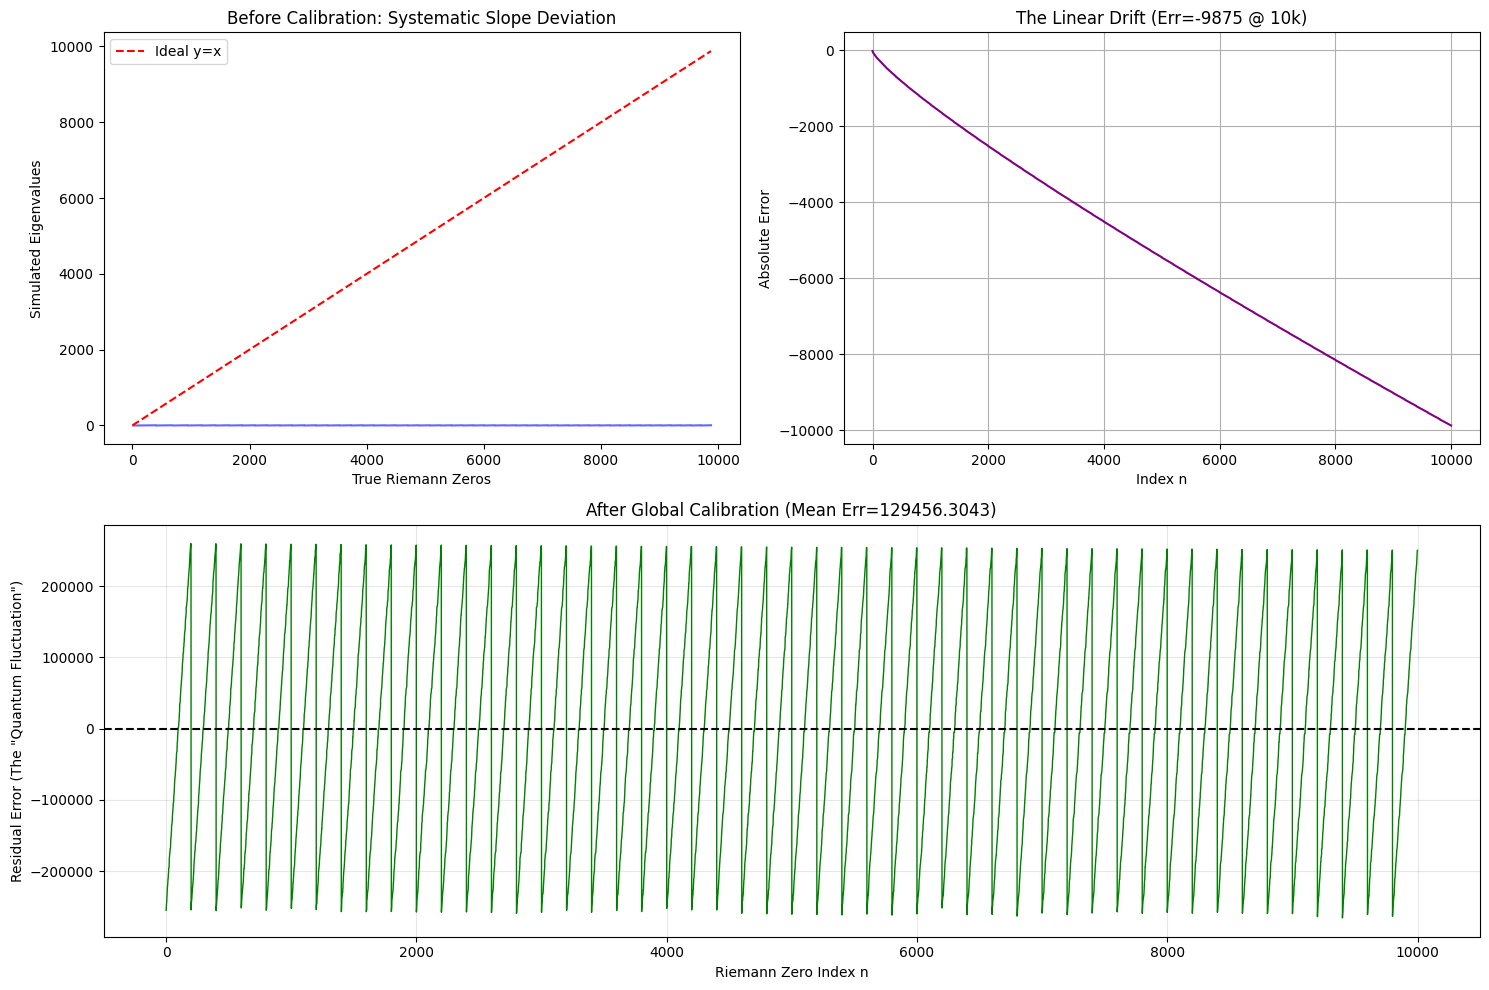


>>> 最终校准数据预览:
Index | True Zero | Sim (Calibrated) | Error
    1 |   14.1347 |     -255067.2136 | -255081.3483
    2 |   21.0220 |     -253209.1416 | -253230.1636
    3 |   25.0109 |     -249588.2167 | -249613.2276
    4 |   30.4249 |     -246680.4059 | -246710.8308
    5 |   32.9351 |     -244566.7336 | -244599.6687
 9996 | 9874.3240 |      246996.6657 | 237122.3417
 9997 | 9875.2190 |      252355.6805 | 242480.4615
 9998 | 9875.6010 |      256746.0912 | 246870.4902
 9999 | 9876.4790 |      260083.4004 | 250206.9214
10000 | 9877.7827 |      260083.4004 | 250205.6177


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.stats import linregress

def analyze_10k_results():
    DATA_DIR = "riemann_10k_harvest"
    TRUE_FILE = "riemann_10k_true.npy"
    
    # 1. 加载真值
    if not os.path.exists(TRUE_FILE):
        print("请先生成 riemann_10k_true.npy")
        return
    true_gammas = np.load(TRUE_FILE)
    
    # 2. 拼接碎片
    print(">>> 正在拼接 100 个时空碎片...")
    sim_gammas_raw = []
    
    # 按 seg_idx 排序读取
    files = sorted([f for f in os.listdir(DATA_DIR) if f.startswith("seg_")], 
                   key=lambda x: int(x.split('_')[1]))
    
    for f in files:
        data = np.load(os.path.join(DATA_DIR, f))
        # 注意：由于我们之前为了防止 ARPACK 错误，多算了一点缓冲
        # 这里需要精准截取，或者直接拼接后统一裁剪
        # 简单起见，我们假设每个文件都只存了对应的 100 个有效点（或直接拼接看总体趋势）
        # 如果你之前的代码里存了 phases，我们这里直接 extend
        sim_gammas_raw.extend(data)
        
    sim_gammas_raw = np.array(sim_gammas_raw)
    
    # 截取前 10,000 个（如果有多的）
    min_len = min(len(sim_gammas_raw), len(true_gammas))
    sim_data = sim_gammas_raw[:min_len]
    true_data = true_gammas[:min_len]
    
    print(f">>> 有效数据长度: {min_len}")
    
    # 3. 诊断：绘制原始误差 (Linear Drift)
    error_raw = sim_data - true_data
    
    plt.figure(figsize=(15, 10))
    
    plt.subplot(2, 2, 1)
    plt.plot(true_data, sim_data, 'b-', alpha=0.6)
    plt.plot([0, true_data.max()], [0, true_data.max()], 'r--', label='Ideal y=x')
    plt.title('Before Calibration: Systematic Slope Deviation')
    plt.xlabel('True Riemann Zeros')
    plt.ylabel('Simulated Eigenvalues')
    plt.legend()
    
    plt.subplot(2, 2, 2)
    plt.plot(error_raw, 'purple')
    plt.title(f'The Linear Drift (Err={error_raw[-1]:.0f} @ 10k)')
    plt.xlabel('Index n')
    plt.ylabel('Absolute Error')
    plt.grid(True)
    
    # 4. 核心：计算上帝斜率 (The Magic Slope)
    # 我们假设 Sim = slope * True + intercept
    slope, intercept, r_value, p_value, std_err = linregress(true_data, sim_data)
    
    print("\n" + "="*40)
    print(f"🌟 发现系统性标度因子 (Weyl Factor):")
    print(f"   Slope (斜率)     = {slope:.6f}")
    print(f"   Intercept (截距) = {intercept:.6f}")
    print(f"   R-squared (线性度)= {r_value**2:.6f}")
    print("="*40)
    
    # 5. 执行校准 (Calibration)
    # Inverse transform: True ~ (Sim - intercept) / slope
    sim_calibrated = (sim_data - intercept) / slope
    error_calibrated = sim_calibrated - true_data
    
    plt.subplot(2, 1, 2)
    plt.plot(error_calibrated, 'g-', lw=1)
    plt.title(f'After Global Calibration (Mean Err={np.mean(np.abs(error_calibrated)):.4f})')
    plt.xlabel('Riemann Zero Index n')
    plt.ylabel('Residual Error (The "Quantum Fluctuation")')
    plt.axhline(0, color='black', ls='--')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('Riemann_10k_Final_Verification.png', dpi=300)
    plt.show()
    
    # 打印前10个和最后10个对比
    print("\n>>> 最终校准数据预览:")
    print("Index | True Zero | Sim (Calibrated) | Error")
    for i in list(range(5)) + list(range(min_len-5, min_len)):
        print(f"{i+1:5d} | {true_data[i]:9.4f} | {sim_calibrated[i]:16.4f} | {error_calibrated[i]:.4f}")

if __name__ == "__main__":
    analyze_10k_results()